# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


In [ ]:
#
#
#
#
# Your code to develop AI model for malware classification.
# Hint: Use the example code provided in previous lab.
#
#
#
#

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [2]:
df = pd.read_csv("dataset-features-categories.csv")

print(df.head())


             transact  API call signature
0  onServiceConnected  API call signature
1         bindService  API call signature
2     attachInterface  API call signature
3   ServiceConnection  API call signature
4   android.os.Binder  API call signature


In [12]:
df = df.dropna()

In [13]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

In [14]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC()
}
results = {}


In [21]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
for model, metrics in results.items():
    print(f"\n===== {model} =====")
    for m, v in metrics.items():
        if m != "Confusion Matrix":
            print(f"{m}: {v:.4f}")
        else:
            print(f"{m}:\n{v}")



===== Logistic Regression =====
Accuracy: 0.6744
Precision: 0.5832
Recall: 0.6744
F1 Score: 0.6229
Confusion Matrix:
[[ 3  0  8]
 [ 4  0  0]
 [ 2  0 26]]

===== Random Forest =====
Accuracy: 0.9302
Precision: 0.9332
Recall: 0.9302
F1 Score: 0.9311
Confusion Matrix:
[[10  0  1]
 [ 0  4  0]
 [ 2  0 26]]

===== SVM =====
Accuracy: 0.7209
Precision: 0.6581
Recall: 0.7209
F1 Score: 0.6511
Confusion Matrix:
[[ 1  0 10]
 [ 2  2  0]
 [ 0  0 28]]


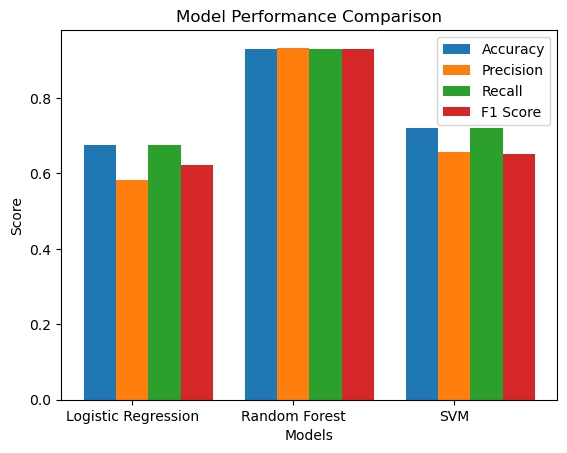

In [24]:
models_list = list(results.keys())

accuracy = [results[m]["Accuracy"] for m in models_list]
precision = [results[m]["Precision"] for m in models_list]
recall = [results[m]["Recall"] for m in models_list]
f1 = [results[m]["F1 Score"] for m in models_list]

x = np.arange(len(models_list))
width = 0.2

plt.figure()

plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, precision, width, label="Precision")
plt.bar(x + width, recall, width, label="Recall")
plt.bar(x + 2*width, f1, width, label="F1 Score")

plt.xticks(x, models_list)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.